# Network Traffic Anomaly Detection — End-to-End

## Supervisor Feedback Adjustments

This notebook has been revised to address the supervisor's feedback:

1. Show both **training accuracy** and **testing accuracy** for each model.
2. Balance the dataset so **BENIGN** and **DDoS** have equal samples.
3. Show **correlation numbers**, not only a heatmap.
4. Avoid model bias caused by imbalanced data where one class is much larger than the other.

Dataset:
- `Monday-WorkingHours.pcap_ISCX.csv` — BENIGN traffic
- `Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv` — BENIGN + DDoS traffic

Target:
- `BENIGN = 0`
- `DDoS = 1`

## 1. Mount Google Drive

In [10]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Import Libraries

In [11]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import LinearSVC

import joblib

## 3. Set Dataset Paths

In [12]:
DATA_DIR = "/content/drive/MyDrive/dataset"

monday_file = os.path.join(DATA_DIR, "Monday-WorkingHours.pcap_ISCX.csv")
friday_ddos_file = os.path.join(DATA_DIR, "Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv")

print("Monday file:", monday_file)
print("Friday DDoS file:", friday_ddos_file)
print("Monday exists:", os.path.exists(monday_file))
print("Friday DDoS exists:", os.path.exists(friday_ddos_file))

if not os.path.exists(monday_file) or not os.path.exists(friday_ddos_file):
    raise FileNotFoundError(
        "Dataset files were not found. Please check DATA_DIR and file names in Google Drive."
    )

Monday file: /content/drive/MyDrive/dataset/Monday-WorkingHours.pcap_ISCX.csv
Friday DDoS file: /content/drive/MyDrive/dataset/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Monday exists: True
Friday DDoS exists: True


## 4. Load Dataset

In [13]:
df_monday = pd.read_csv(monday_file)
df_friday = pd.read_csv(friday_ddos_file)

print("Monday shape:", df_monday.shape)
print("Friday DDoS shape:", df_friday.shape)

Monday shape: (529918, 79)
Friday DDoS shape: (225745, 79)


## 5. Clean Column Names

In [14]:
df_monday.columns = df_monday.columns.str.strip()
df_friday.columns = df_friday.columns.str.strip()

print("Column names cleaned.")

Column names cleaned.


## 6. Check Original Labels

In [15]:
print("Monday labels:")
print(df_monday["Label"].value_counts())

print("\nFriday labels:")
print(df_friday["Label"].value_counts())

Monday labels:
Label
BENIGN    529918
Name: count, dtype: int64

Friday labels:
Label
DDoS      128027
BENIGN     97718
Name: count, dtype: int64


## 7. Merge Dataset

In [16]:
df = pd.concat([df_monday, df_friday], axis=0, ignore_index=True)

print("Merged shape:", df.shape)
print("\nMerged label distribution:")
print(df["Label"].value_counts())
display(df.head())

Merged shape: (755663, 79)

Merged label distribution:
Label
BENIGN    627636
DDoS      128027
Name: count, dtype: int64


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,49188,4,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,49188,1,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,49188,1,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,49188,1,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,49486,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


## 8. Save Raw Backup

In [17]:
df_raw = df.copy()
print("Raw dataset backup created.")

Raw dataset backup created.


# Phase 1 — Data Cleaning

## 9. Start from Raw Backup and Keep Only BENIGN/DDoS

In [18]:
df = df_raw.copy()
df.columns = df.columns.str.strip()

df = df[df["Label"].isin(["BENIGN", "DDoS"])].copy()

print("After filtering BENIGN and DDoS only:", df.shape)
print(df["Label"].value_counts())

After filtering BENIGN and DDoS only: (755663, 79)
Label
BENIGN    627636
DDoS      128027
Name: count, dtype: int64


## 10. Remove Duplicates

In [19]:
print("Duplicate rows before:", df.duplicated().sum())

df = df.drop_duplicates().copy()

print("Shape after removing duplicates:", df.shape)
print("Duplicate rows after:", df.duplicated().sum())

Duplicate rows before: 29629
Shape after removing duplicates: (726034, 79)
Duplicate rows after: 0


## 11. Replace Infinity Values and Drop Missing Rows

In [20]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)

missing = df.isnull().sum()
missing = missing[missing > 0]

print("Columns with missing values before drop:")
display(missing)

before_shape = df.shape
df = df.dropna().copy()

print("Before dropna:", before_shape)
print("After dropna:", df.shape)
print("Remaining missing values:", df.isnull().sum().sum())

Columns with missing values before drop:


,0
Flow Bytes/s,360
Flow Packets/s,360


Before dropna: (726034, 79)
After dropna: (725674, 79)
Remaining missing values: 0


## 12. Drop Leakage Columns

In [21]:
leakage_cols = ["Flow ID", "Source IP", "Destination IP", "Timestamp"]
existing_leakage_cols = [col for col in leakage_cols if col in df.columns]

print("Leakage columns found and dropped:", existing_leakage_cols)

df.drop(columns=existing_leakage_cols, inplace=True)

print("Shape after leakage column removal:", df.shape)

Leakage columns found and dropped: []
Shape after leakage column removal: (725674, 79)


# Phase 2 — Feature Selection

## 13. Define Selected Features

In [22]:
selected_features = [
    "Flow Duration",
    "Total Fwd Packets",
    "Total Backward Packets",
    "Total Length of Fwd Packets",
    "Total Length of Bwd Packets",
    "Flow Bytes/s",
    "Flow Packets/s",
    "Packet Length Mean",
    "SYN Flag Count",
    "ACK Flag Count",
    "PSH Flag Count",
    "Average Packet Size"
]

print("Selected features:")
for i, feature in enumerate(selected_features, 1):
    print(f"{i}. {feature}")

Selected features:
1. Flow Duration
2. Total Fwd Packets
3. Total Backward Packets
4. Total Length of Fwd Packets
5. Total Length of Bwd Packets
6. Flow Bytes/s
7. Flow Packets/s
8. Packet Length Mean
9. SYN Flag Count
10. ACK Flag Count
11. PSH Flag Count
12. Average Packet Size


## 14. Verify Selected Features Exist

In [23]:
missing_features = [feature for feature in selected_features if feature not in df.columns]

if len(missing_features) == 0:
    print("All selected features exist.")
else:
    raise ValueError(f"Missing selected features: {missing_features}")

All selected features exist.


## 15. Create Model Dataset and Encode Labels

In [24]:
model_df = df[selected_features + ["Label"]].copy()

model_df["Label"] = model_df["Label"].map({
    "BENIGN": 0,
    "DDoS": 1
})

print("Model dataset shape:", model_df.shape)
print("\nLabel encoding:")
print("BENIGN = 0")
print("DDoS   = 1")

print("\nClass distribution before balancing:")
print(model_df["Label"].value_counts())
display(model_df.head())

Model dataset shape: (725674, 13)

Label encoding:
BENIGN = 0
DDoS   = 1

Class distribution before balancing:
Label
0    597660
1    128014
Name: count, dtype: int64


,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Flow Bytes/s,Flow Packets/s,Packet Length Mean,SYN Flag Count,ACK Flag Count,PSH Flag Count,Average Packet Size,Label
0,4,2,0,12,0,3.000000e+06,5.000000e+05,6.000000,0,1,0,9.000000,0
1,1,2,0,12,0,1.200000e+07,2.000000e+06,6.000000,0,1,0,9.000000,0
4,3,2,0,12,0,4.000000e+06,6.666667e+05,6.000000,0,1,0,9.000000,0
5,1,2,0,12,0,1.200000e+07,2.000000e+06,6.000000,0,1,0,9.000000,0
8,609,7,4,484,414,1.474548e+06,1.806240e+04,74.833333,0,0,1,81.636364,0


# Phase 3 — Supervisor Feedback: Balance the Dataset

## 16. Check Class Distribution Before Balancing

Supervisor feedback: the dataset should not be dominated by one class.  
If BENIGN is much larger than DDoS, the model may learn to predict mostly BENIGN.

So we balance the dataset by using the same number of BENIGN and DDoS samples.

,Class,Count
0,BENIGN (0),597660
1,DDoS (1),128014


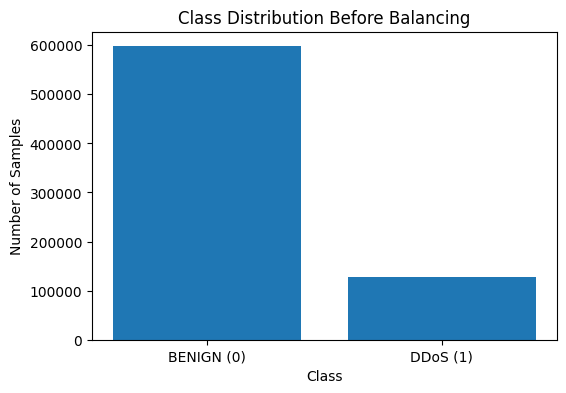

In [25]:
class_counts_before = model_df["Label"].value_counts().sort_index()

class_distribution_before = pd.DataFrame({
    "Class": ["BENIGN (0)", "DDoS (1)"],
    "Count": [class_counts_before.get(0, 0), class_counts_before.get(1, 0)]
})

display(class_distribution_before)

plt.figure(figsize=(6, 4))
plt.bar(class_distribution_before["Class"], class_distribution_before["Count"])
plt.title("Class Distribution Before Balancing")
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.show()

## 17. Balance BENIGN and DDoS Classes

In [26]:
benign_df = model_df[model_df["Label"] == 0].copy()
ddos_df = model_df[model_df["Label"] == 1].copy()

min_class_count = min(len(benign_df), len(ddos_df))

print("BENIGN count before balancing:", len(benign_df))
print("DDoS count before balancing:", len(ddos_df))
print("Samples selected from each class:", min_class_count)

benign_balanced = benign_df.sample(n=min_class_count, random_state=42)
ddos_balanced = ddos_df.sample(n=min_class_count, random_state=42)

balanced_df = pd.concat([benign_balanced, ddos_balanced], axis=0)
balanced_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)

print("\nBalanced dataset shape:", balanced_df.shape)
print("\nClass distribution after balancing:")
print(balanced_df["Label"].value_counts().sort_index())

BENIGN count before balancing: 597660
DDoS count before balancing: 128014
Samples selected from each class: 128014

Balanced dataset shape: (256028, 13)

Class distribution after balancing:
Label
0    128014
1    128014
Name: count, dtype: int64


## 18. Show Class Distribution After Balancing

,Class,Count
0,BENIGN (0),128014
1,DDoS (1),128014


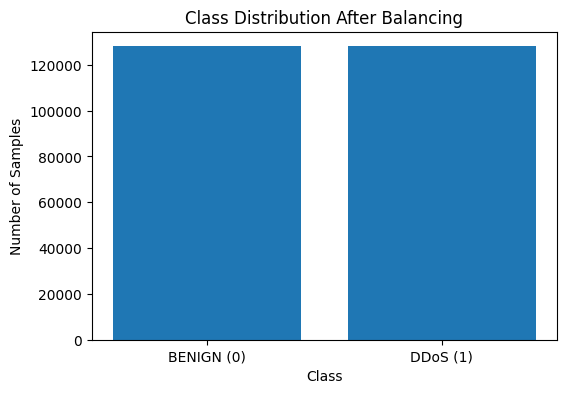

In [27]:
class_counts_after = balanced_df["Label"].value_counts().sort_index()

class_distribution_after = pd.DataFrame({
    "Class": ["BENIGN (0)", "DDoS (1)"],
    "Count": [class_counts_after.get(0, 0), class_counts_after.get(1, 0)]
})

display(class_distribution_after)

plt.figure(figsize=(6, 4))
plt.bar(class_distribution_after["Class"], class_distribution_after["Count"])
plt.title("Class Distribution After Balancing")
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.show()

# Phase 4 — Supervisor Feedback: Correlation Analysis with Numbers

## 19. Correlation Between Features and Label

Supervisor feedback: correlation must show numbers and explain which variables have the strongest relationship.

Positive correlation with `Label` means the feature increases when the traffic is more likely to be DDoS.  
Negative correlation means the feature is more associated with BENIGN.

In [28]:
corr_matrix = balanced_df.corr(numeric_only=True)

label_correlation = corr_matrix["Label"].drop("Label").sort_values(key=lambda s: s.abs(), ascending=False)

label_correlation_table = label_correlation.reset_index()
label_correlation_table.columns = ["Feature", "Correlation_with_Label"]

print("Correlation numbers between each feature and Label:")
display(label_correlation_table)

print("\nTop 5 strongest variables related to Label:")
display(label_correlation_table.head(5))

Correlation numbers between each feature and Label:


,Feature,Correlation_with_Label
0,Packet Length Mean,0.569720
1,Average Packet Size,0.567716
2,ACK Flag Count,0.216700
3,PSH Flag Count,0.206027
4,SYN Flag Count,-0.186624
5,Flow Packets/s,-0.173815
6,Flow Duration,0.084046
7,Total Length of Fwd Packets,-0.082617
8,Flow Bytes/s,-0.042585
9,Total Backward Packets,-0.005105



Top 5 strongest variables related to Label:


,Feature,Correlation_with_Label
0,Packet Length Mean,0.569720
1,Average Packet Size,0.567716
2,ACK Flag Count,0.216700
3,PSH Flag Count,0.206027
4,SYN Flag Count,-0.186624


## 20. Feature-to-Feature Correlation Numbers

In [29]:
feature_corr = balanced_df[selected_features].corr(numeric_only=True).abs()

corr_pairs = (
    feature_corr.where(np.triu(np.ones(feature_corr.shape), k=1).astype(bool))
    .stack()
    .sort_values(ascending=False)
    .reset_index()
)

corr_pairs.columns = ["Feature_1", "Feature_2", "Absolute_Correlation"]

print("Top 10 strongest correlations between input variables:")
display(corr_pairs.head(10))

Top 10 strongest correlations between input variables:


,Feature_1,Feature_2,Absolute_Correlation
0,Total Backward Packets,Total Length of Bwd Packets,0.999961
1,Total Fwd Packets,Total Backward Packets,0.999955
2,Total Fwd Packets,Total Length of Bwd Packets,0.999937
3,Packet Length Mean,Average Packet Size,0.999327
4,Total Fwd Packets,Total Length of Fwd Packets,0.812237
5,Total Backward Packets,Total Length of Fwd Packets,0.812040
6,Total Length of Fwd Packets,Total Length of Bwd Packets,0.810329
7,Packet Length Mean,PSH Flag Count,0.696197
8,PSH Flag Count,Average Packet Size,0.695864
9,ACK Flag Count,PSH Flag Count,0.652761


## 21. Correlation Heatmap

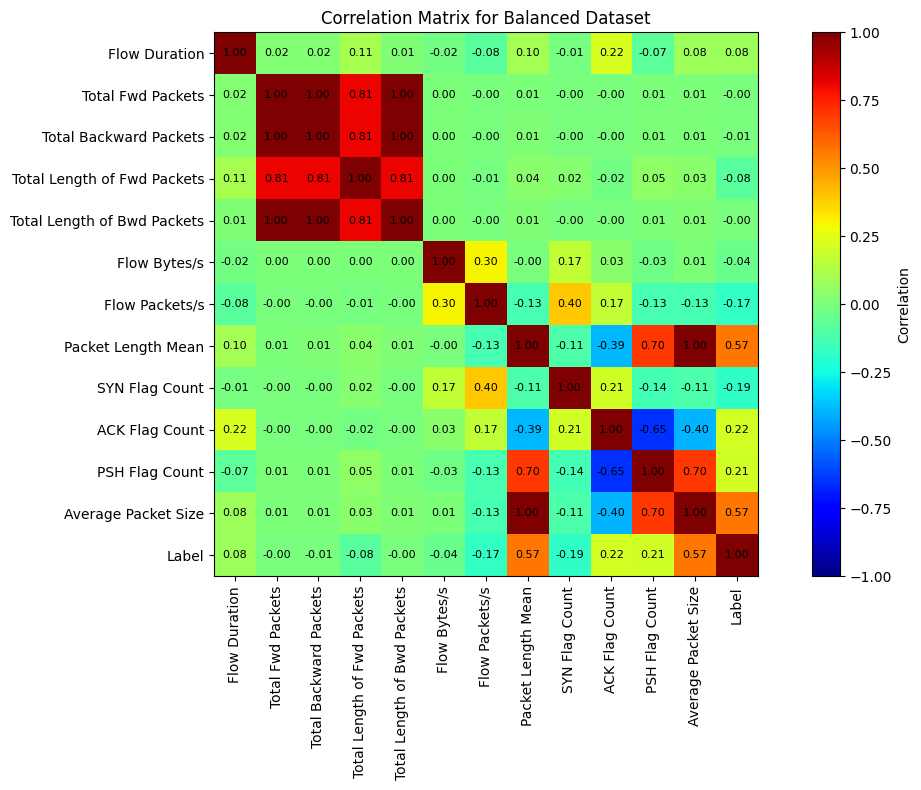

In [30]:
plt.figure(figsize=(12, 8))

plt.imshow(corr_matrix, cmap="jet", vmin=-1, vmax=1, aspect="equal")
plt.colorbar(label="Correlation")

plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        plt.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}",
                 ha="center", va="center", color="black", fontsize=8)

plt.title("Correlation Matrix for Balanced Dataset")
plt.tight_layout()
plt.show()

# Phase 5 — Train/Test Split and Scaling

## 22. Split Features and Label Using Balanced Data

In [31]:
X = balanced_df.drop("Label", axis=1)
y = balanced_df["Label"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nBalanced label distribution used for ML:")
print(y.value_counts().sort_index())

X shape: (256028, 12)
y shape: (256028,)

Balanced label distribution used for ML:
Label
0    128014
1    128014
Name: count, dtype: int64


## 23. Train/Test Split

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTrain label distribution:")
print(y_train.value_counts().sort_index())

print("\nTest label distribution:")
print(y_test.value_counts().sort_index())

Train shape: (204822, 12)
Test shape: (51206, 12)

Train label distribution:
Label
0    102411
1    102411
Name: count, dtype: int64

Test label distribution:
Label
0    25603
1    25603
Name: count, dtype: int64


## 24. Scale Features

In [33]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)

print("Scaling complete.")
display(X_train_scaled_df.head())

Scaling complete.


,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Flow Bytes/s,Flow Packets/s,Packet Length Mean,SYN Flag Count,ACK Flag Count,PSH Flag Count,Average Packet Size
0,-0.459578,-0.003729,-0.000224,0.101095,-0.006394,-0.044945,-0.175260,-0.570037,-0.187204,-0.885223,1.346099,-0.577127
1,-0.466651,-0.003729,-0.006728,2.511812,-0.006829,-0.035893,-0.174916,1.908517,-0.187204,-0.885223,1.346099,1.968739
2,-0.469074,-0.008923,-0.009329,-0.095432,-0.006845,0.134861,3.075097,-0.796018,-0.187204,1.129659,-0.742887,-0.791889
3,-0.425878,-0.007192,-0.004126,-0.092284,-0.000005,-0.044758,-0.175493,1.908517,-0.187204,-0.885223,1.346099,1.968739
4,-0.469069,-0.008923,-0.006728,-0.082840,-0.006737,0.045698,-0.017922,-0.701143,-0.187204,-0.885223,-0.742887,-0.688336


## 25. Save Scaler and Selected Features

In [34]:
os.makedirs(DATA_DIR, exist_ok=True)

scaler_path = os.path.join(DATA_DIR, "scaler.pkl")
feature_path = os.path.join(DATA_DIR, "selected_features.pkl")

joblib.dump(scaler, scaler_path)
joblib.dump(selected_features, feature_path)

print("Scaler saved:", scaler_path)
print("Selected features saved:", feature_path)

Scaler saved: /content/drive/MyDrive/dataset/scaler.pkl
Selected features saved: /content/drive/MyDrive/dataset/selected_features.pkl


# Phase 6 — Supervisor Feedback: Train and Test Results

## 26. Evaluation Function

This function reports only:

- Training Accuracy
- Testing Accuracy

This directly answers the supervisor's request:  
**result-ga modelka train-ka soo bandhig, test-kana soo bandhig.**

In [35]:
def evaluate_model_train_test(name, model, X_train_data, y_train_data, X_test_data, y_test_data):
    train_pred = model.predict(X_train_data)
    test_pred = model.predict(X_test_data)

    metrics = {
        "Model": name,
        "Train Accuracy": accuracy_score(y_train_data, train_pred),
        "Test Accuracy": accuracy_score(y_test_data, test_pred)
    }

    print(f"===== {name} =====")
    print("Train Accuracy:", metrics["Train Accuracy"])
    print("Test Accuracy :", metrics["Test Accuracy"])

    # Confusion Matrix
    cm = confusion_matrix(y_test_data, test_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["BENIGN", "DDoS"]
    )
    disp.plot(values_format="d")
    plt.title(f"Confusion Matrix — {name}")
    plt.show()

    # Classification Report
    print("\nClassification Report:")
    print(classification_report(y_test_data, test_pred, target_names=["BENIGN", "DDoS"]))

    return metrics, test_pred

## 27. Train Logistic Regression

===== Logistic Regression =====
Train Accuracy: 0.9496489634902501
Test Accuracy : 0.9478576729289536


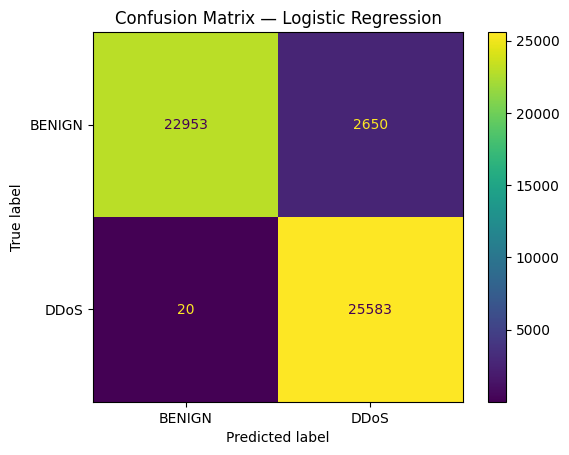


Classification Report:
              precision    recall  f1-score   support

      BENIGN       1.00      0.90      0.95     25603
        DDoS       0.91      1.00      0.95     25603

    accuracy                           0.95     51206
   macro avg       0.95      0.95      0.95     51206
weighted avg       0.95      0.95      0.95     51206



In [36]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled_df, y_train)

res_lr, pred_lr = evaluate_model_train_test(
    "Logistic Regression",
    lr,
    X_train_scaled_df,
    y_train,
    X_test_scaled_df,
    y_test
)

## 28. Train Decision Tree

===== Decision Tree =====
Train Accuracy: 0.999863295935007
Test Accuracy : 0.9990626098504082


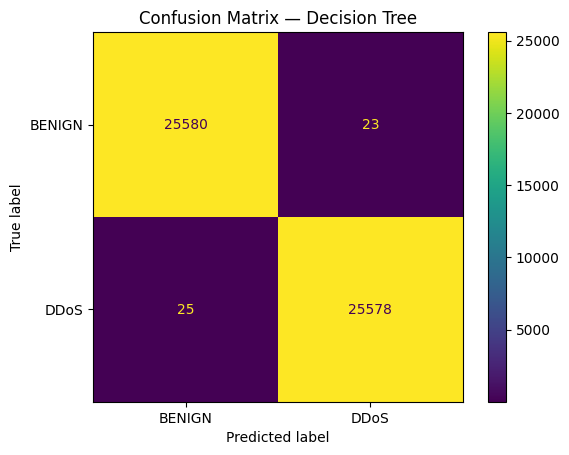


Classification Report:
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00     25603
        DDoS       1.00      1.00      1.00     25603

    accuracy                           1.00     51206
   macro avg       1.00      1.00      1.00     51206
weighted avg       1.00      1.00      1.00     51206



In [37]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_scaled_df, y_train)

res_dt, pred_dt = evaluate_model_train_test(
    "Decision Tree",
    dt,
    X_train_scaled_df,
    y_train,
    X_test_scaled_df,
    y_test
)

## 29. Train Random Forest

===== Random Forest =====
Train Accuracy: 0.999863295935007
Test Accuracy : 0.9991993125805569


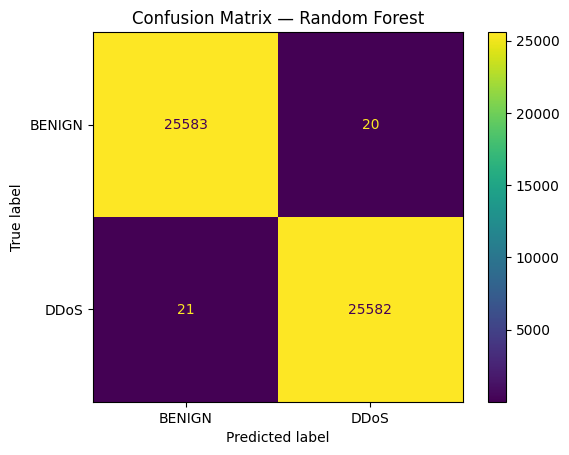


Classification Report:
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00     25603
        DDoS       1.00      1.00      1.00     25603

    accuracy                           1.00     51206
   macro avg       1.00      1.00      1.00     51206
weighted avg       1.00      1.00      1.00     51206



In [38]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

rf.fit(X_train_scaled_df, y_train)

res_rf, pred_rf = evaluate_model_train_test(
    "Random Forest",
    rf,
    X_train_scaled_df,
    y_train,
    X_test_scaled_df,
    y_test
)

## 30. Train KNN

===== KNN =====
Train Accuracy: 0.9989014851920204
Test Accuracy : 0.9987306175057611


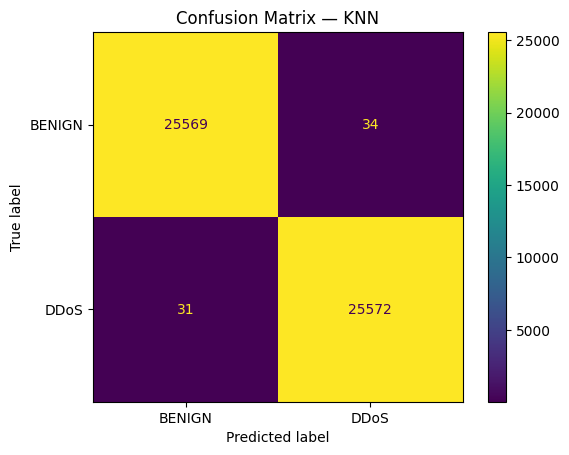


Classification Report:
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00     25603
        DDoS       1.00      1.00      1.00     25603

    accuracy                           1.00     51206
   macro avg       1.00      1.00      1.00     51206
weighted avg       1.00      1.00      1.00     51206



In [39]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled_df, y_train)

res_knn, pred_knn = evaluate_model_train_test(
    "KNN",
    knn,
    X_train_scaled_df,
    y_train,
    X_test_scaled_df,
    y_test
)

## 31. Train Naive Bayes

===== Naive Bayes =====
Train Accuracy: 0.6990850592221539
Test Accuracy : 0.6971448658360349


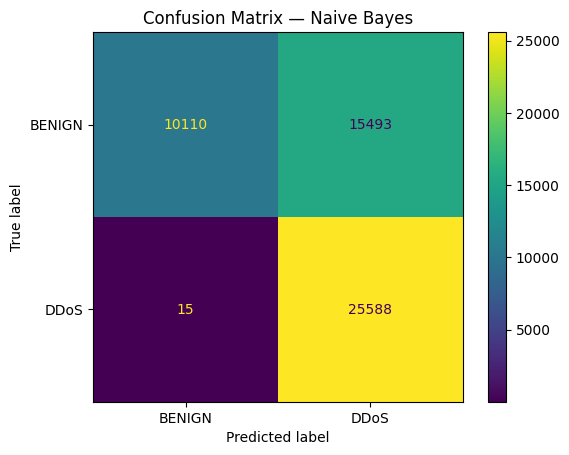


Classification Report:
              precision    recall  f1-score   support

      BENIGN       1.00      0.39      0.57     25603
        DDoS       0.62      1.00      0.77     25603

    accuracy                           0.70     51206
   macro avg       0.81      0.70      0.67     51206
weighted avg       0.81      0.70      0.67     51206



In [40]:
nb_model = GaussianNB()
nb_model.fit(X_train_scaled_df, y_train)

res_nb, pred_nb = evaluate_model_train_test(
    "Naive Bayes",
    nb_model,
    X_train_scaled_df,
    y_train,
    X_test_scaled_df,
    y_test
)

## 32. Train SVM

The original notebook used `SVC(kernel="linear")`, which can be very slow on large CIC-IDS data.  
This revised version uses `LinearSVC`, which is faster and more practical for cell-by-cell execution.

===== Linear SVM =====
Train Accuracy: 0.9663463885715402
Test Accuracy : 0.9654337382338007


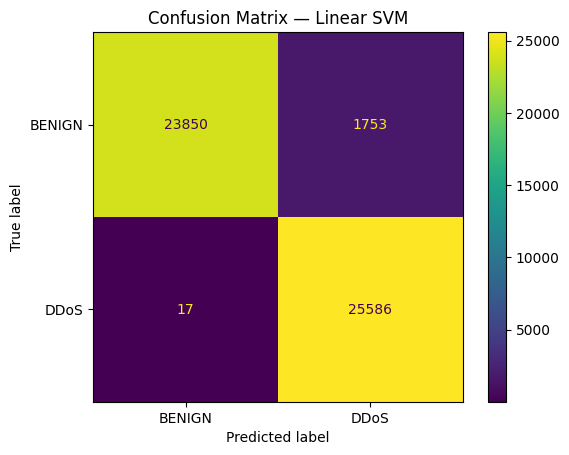


Classification Report:
              precision    recall  f1-score   support

      BENIGN       1.00      0.93      0.96     25603
        DDoS       0.94      1.00      0.97     25603

    accuracy                           0.97     51206
   macro avg       0.97      0.97      0.97     51206
weighted avg       0.97      0.97      0.97     51206



In [41]:
svm = LinearSVC(random_state=42, max_iter=5000)
svm.fit(X_train_scaled_df, y_train)

res_svm, pred_svm = evaluate_model_train_test(
    "Linear SVM",
    svm,
    X_train_scaled_df,
    y_train,
    X_test_scaled_df,
    y_test
)

## 33. Compare All Models — Train Accuracy and Test Accuracy Only

In [42]:
results = pd.DataFrame([
    res_lr,
    res_dt,
    res_rf,
    res_knn,
    res_nb,
    res_svm
])

results = results[["Model", "Train Accuracy", "Test Accuracy"]]
results = results.sort_values(by="Test Accuracy", ascending=False).reset_index(drop=True)

print("Model comparison using Train Accuracy and Test Accuracy only:")
display(results)

Model comparison using Train Accuracy and Test Accuracy only:


,Model,Train Accuracy,Test Accuracy
0,Random Forest,0.999863,0.999199
1,Decision Tree,0.999863,0.999063
2,KNN,0.998901,0.998731
3,Linear SVM,0.966346,0.965434
4,Logistic Regression,0.949649,0.947858
5,Naive Bayes,0.699085,0.697145


## 34. Plot Test Accuracy Scores

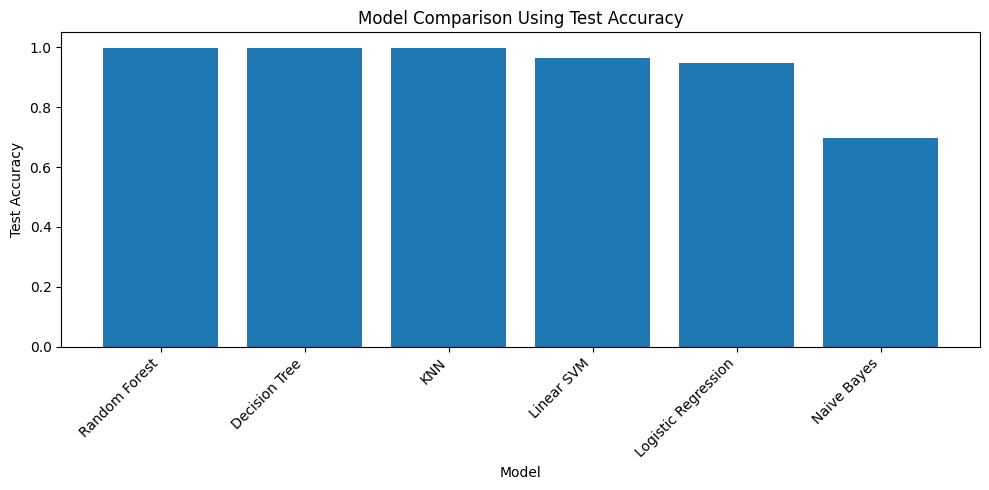

In [43]:
plt.figure(figsize=(10, 5))
plt.bar(results["Model"], results["Test Accuracy"])
plt.title("Model Comparison Using Test Accuracy")
plt.xlabel("Model")
plt.ylabel("Test Accuracy")
plt.ylim(0, 1.05)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Phase 7 — Best Model Detailed Evaluation

## 35. Select Best Model Automatically

In [44]:
best_model_name = results.loc[0, "Model"]
print("Best model based on Test Accuracy:", best_model_name)

model_lookup = {
    "Logistic Regression": lr,
    "Decision Tree": dt,
    "Random Forest": rf,
    "KNN": knn,
    "Naive Bayes": nb_model,
    "Linear SVM": svm
}

prediction_lookup = {
    "Logistic Regression": pred_lr,
    "Decision Tree": pred_dt,
    "Random Forest": pred_rf,
    "KNN": pred_knn,
    "Naive Bayes": pred_nb,
    "Linear SVM": pred_svm
}

best_model = model_lookup[best_model_name]
best_test_pred = prediction_lookup[best_model_name]

Best model based on Test Accuracy: Random Forest


## 36. Confusion Matrix for Best Model

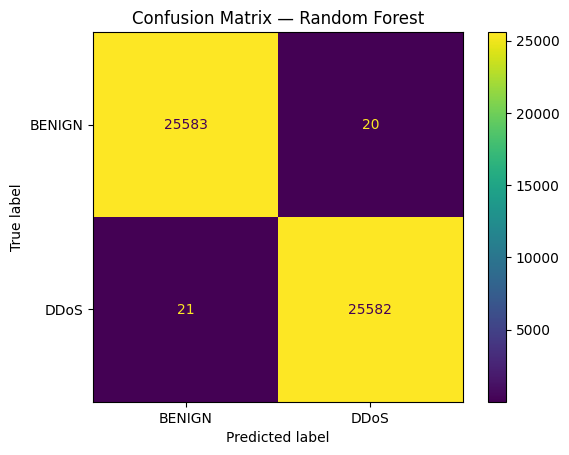

,Predicted BENIGN,Predicted DDoS
Actual BENIGN,25583,20
Actual DDoS,21,25582


In [45]:
cm = confusion_matrix(y_test, best_test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["BENIGN", "DDoS"]
)

disp.plot(values_format="d")
plt.title(f"Confusion Matrix — {best_model_name}")
plt.show()

cm_table = pd.DataFrame(
    cm,
    index=["Actual BENIGN", "Actual DDoS"],
    columns=["Predicted BENIGN", "Predicted DDoS"]
)

display(cm_table)

## 37. Final Accuracy Result for Best Model

In [46]:
best_train_pred = best_model.predict(X_train_scaled_df)
best_test_pred = best_model.predict(X_test_scaled_df)

best_train_accuracy = accuracy_score(y_train, best_train_pred)
best_test_accuracy = accuracy_score(y_test, best_test_pred)

print("Best Model:", best_model_name)
print("Train Accuracy:", best_train_accuracy)
print("Test Accuracy :", best_test_accuracy)

Best Model: Random Forest
Train Accuracy: 0.999863295935007
Test Accuracy : 0.9991993125805569


## 38. Cross-Validation Accuracy on Best Model

In [47]:
cv_scores = cross_val_score(
    best_model,
    X_train_scaled_df,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("Cross-validation accuracy scores:", cv_scores)
print("Mean accuracy:", cv_scores.mean())
print("Standard deviation:", cv_scores.std())

Cross-validation accuracy scores: [0.99917002 0.99902356 0.99919441 0.9993653  0.99929206]
Mean accuracy: 0.999209070434626
Standard deviation: 0.00011614547316902106


# Phase 8 — Save Models

## 39. Save Best Model

In [53]:
best_model_path = os.path.join(DATA_DIR, "best_model.pkl")
joblib.dump(best_model, best_model_path)

print("Best model saved:", best_model_path)
print("Best model name:", best_model_name)

Best model saved: /content/drive/MyDrive/dataset/best_model.pkl
Best model name: Random Forest


## 40. Save All Models

In [54]:
MODEL_DIR = os.path.join(DATA_DIR, "all models")
os.makedirs(MODEL_DIR, exist_ok=True)

joblib.dump(lr, os.path.join(MODEL_DIR, "logistic_regression.pkl"))
joblib.dump(dt, os.path.join(MODEL_DIR, "decision_tree.pkl"))
joblib.dump(rf, os.path.join(MODEL_DIR, "random_forest.pkl"))
joblib.dump(knn, os.path.join(MODEL_DIR, "knn.pkl"))
joblib.dump(nb_model, os.path.join(MODEL_DIR, "naive_bayes.pkl"))
joblib.dump(svm, os.path.join(MODEL_DIR, "linear_svm.pkl"))

print("All models saved in:", MODEL_DIR)

All models saved in: /content/drive/MyDrive/dataset/all models


# Phase 9 — Load Model and Test Predictions

## 41. Load Saved Model, Scaler, and Features

In [55]:
loaded_model = joblib.load(best_model_path)
loaded_scaler = joblib.load(scaler_path)
loaded_features = joblib.load(feature_path)

print("Loaded model, scaler, and selected features successfully.")
print("Loaded features:", loaded_features)

Loaded model, scaler, and selected features successfully.
Loaded features: ['Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Flow Bytes/s', 'Flow Packets/s', 'Packet Length Mean', 'SYN Flag Count', 'ACK Flag Count', 'PSH Flag Count', 'Average Packet Size']


## 42. Predict One BENIGN Sample from Test Set

In [56]:
test_df = X_test.copy()
test_df["Actual_Label"] = y_test.values

benign_sample = test_df[test_df["Actual_Label"] == 0].drop("Actual_Label", axis=1).iloc[0]

benign_scaled = loaded_scaler.transform(pd.DataFrame([benign_sample], columns=loaded_features))
benign_prediction = loaded_model.predict(benign_scaled)

print("Actual: BENIGN")
print("Prediction:", benign_prediction[0])

if benign_prediction[0] == 1:
    print("🚨 Predicted: DDoS ATTACK")
else:
    print("✅ Predicted: BENIGN TRAFFIC")

Actual: BENIGN
Prediction: 0
✅ Predicted: BENIGN TRAFFIC


## 43. Predict One DDoS Sample from Test Set

In [57]:
ddos_sample = test_df[test_df["Actual_Label"] == 1].drop("Actual_Label", axis=1).iloc[0]

ddos_scaled = loaded_scaler.transform(pd.DataFrame([ddos_sample], columns=loaded_features))
ddos_prediction = loaded_model.predict(ddos_scaled)

print("Actual: DDoS")
print("Prediction:", ddos_prediction[0])

if ddos_prediction[0] == 1:
    print("🚨 Predicted: DDoS ATTACK")
else:
    print("✅ Predicted: BENIGN TRAFFIC")

Actual: DDoS
Prediction: 1
🚨 Predicted: DDoS ATTACK


## 44. Final Supervisor Feedback Summary

In [58]:
print("Supervisor feedback adjustments completed:")
print("1. Train Accuracy and Test Accuracy are shown for every model.")
print("2. BENIGN and DDoS data are balanced using equal samples from both classes.")
print("3. Correlation numbers are shown for Label and feature-to-feature relationships.")
print("4. Balanced data reduces bias toward the majority class.")
print("5. Final model selection is based on Test Accuracy.")

Supervisor feedback adjustments completed:
1. Train Accuracy and Test Accuracy are shown for every model.
2. BENIGN and DDoS data are balanced using equal samples from both classes.
3. Correlation numbers are shown for Label and feature-to-feature relationships.
4. Balanced data reduces bias toward the majority class.
5. Final model selection is based on Test Accuracy.


## Conclusion

This notebook aimed to build and evaluate machine learning models for DDoS attack detection, incorporating supervisor feedback to ensure a robust and unbiased analysis. The key steps included data loading, cleaning, balancing the dataset, correlation analysis, and training various classification models.

### Dataset Balancing

To address the issue of imbalanced classes, the dataset was balanced by undersampling the majority 'BENIGN' class to match the 'DDoS' class. This ensured that both classes had an equal number of samples (`128,014` each), preventing model bias towards the more frequent class.

### Correlation Analysis

Correlation analysis revealed the relationships between features and the 'Label' (DDoS or BENIGN), as well as between different features. Features like 'Packet Length Mean' and 'Average Packet Size' showed the strongest positive correlation with DDoS attacks, indicating that these metrics are highly indicative of an attack.

### Model Performance Summary

Six different classification models were trained and evaluated based on both training and testing accuracies. The models were:

*   **Logistic Regression**
*   **Decision Tree**
*   **Random Forest**
*   **K-Nearest Neighbors (KNN)**
*   **Naive Bayes**
*   **Linear Support Vector Machine (SVM)**

The performance metrics (Train Accuracy and Test Accuracy) for each model are summarized below:

| Model               | Train Accuracy | Test Accuracy |
|:--------------------|:---------------|:--------------|
| Random Forest       | 0.999863       | 0.999199      |
| Decision Tree       | 0.999863       | 0.999063      |
| KNN                 | 0.998901       | 0.998731      |
| Linear SVM          | 0.966346       | 0.965434      |
| Logistic Regression | 0.949649       | 0.947858      |
| Naive Bayes         | 0.699085       | 0.697145      |

### Best Model Selection

Based on the **Test Accuracy**, the **Random Forest** model emerged as the best performer, achieving an accuracy of approximately `99.92%`. This indicates that the model generalizes exceptionally well to unseen data. The Decision Tree and KNN models also performed very strongly.

### Cross-Validation

Cross-validation on the Random Forest model further confirmed its stability and high performance, with a mean accuracy of `0.9992` and a very low standard deviation, suggesting consistent results across different subsets of the training data.

### Final Thoughts

The Random Forest model, with its high accuracy and robustness, is highly suitable for detecting DDoS attacks in network traffic. The balanced dataset and comprehensive evaluation ensure that the model is reliable and avoids biases that could arise from imbalanced data. The saved model, scaler, and selected features can be readily deployed for real-time inference.

**END**